In [1]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt
type_count = df['type'].value_counts()

In [2]:
df = pd.read_excel('/content/Netflix_data.csv.xlsx')
print("DataFrame Info:")
df.info()
print("\nDescriptive Statistics:")
df.describe()
display(df.head())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB

Descriptive Statistics:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
print(type_count)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


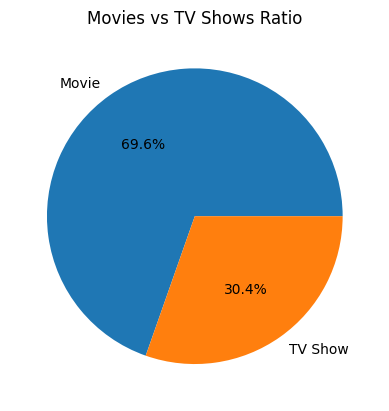

In [6]:
import matplotlib.pyplot as plt

plt.figure()
type_count.plot(kind='pie',
                autopct='%1.1f%%') # Fixed the typo here
plt.title('Movies vs TV Shows Ratio')
plt.ylabel('') # This hides the default 'count' label on the y-axis
plt.show()

International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


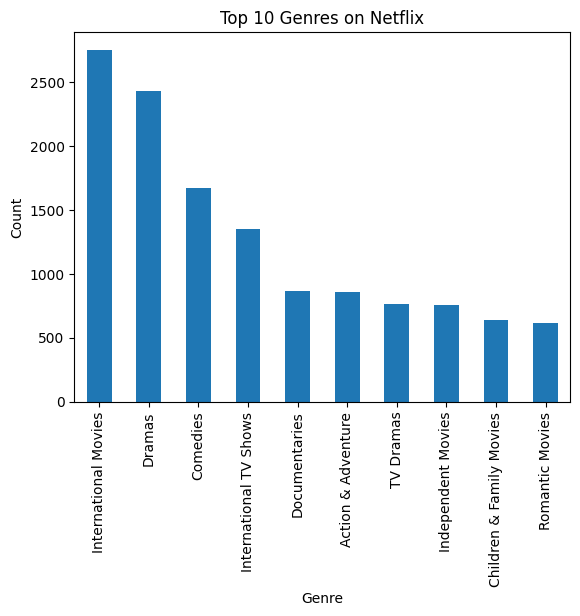

In [7]:
# Split genres (listed_in column usually contains genres)
genres = df['listed_in'].str.split(', ', expand=True).stack()

# Count genres
genre_count = genres.value_counts().head(10)

print(genre_count)

# Plot bar graph
plt.figure()
genre_count.plot(kind='bar')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.show()

release_year
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64


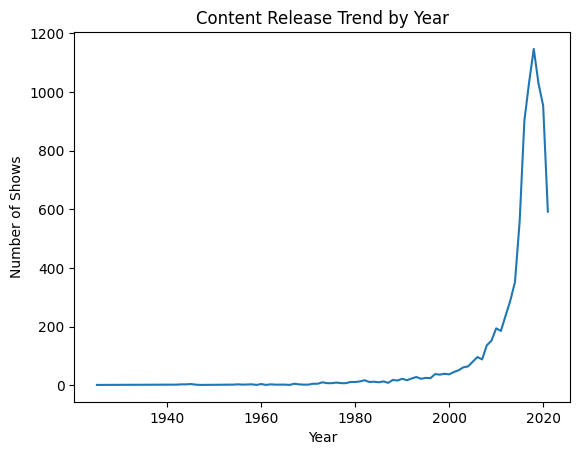

In [8]:
# Count content per year
year_count = df['release_year'].value_counts().sort_index()

print(year_count.tail())  # latest years

# Plot line graph
plt.figure()
year_count.plot()
plt.title('Content Release Trend by Year')
plt.xlabel('Year')
plt.ylabel('Number of Shows')
plt.show()

United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


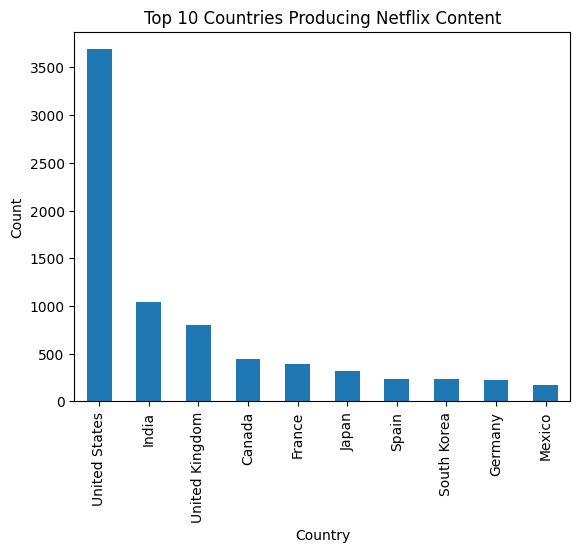

In [9]:
# Split country column
countries = df['country'].dropna().str.split(', ', expand=True).stack()

country_count = countries.value_counts().head(10)

print(country_count)

# Plot
plt.figure()
country_count.plot(kind='bar')
plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64


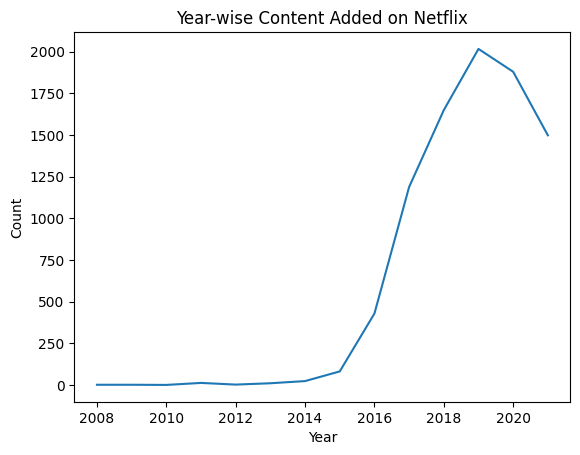

In [10]:
# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract year added
df['year_added'] = df['date_added'].dt.year

year_added_count = df['year_added'].value_counts().sort_index()

print(year_added_count)

# Plot
plt.figure()
year_added_count.plot()
plt.title('Year-wise Content Added on Netflix')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
Name: count, dtype: int64


<Axes: title={'center': 'Most Frequent Ratings'}, xlabel='rating'>

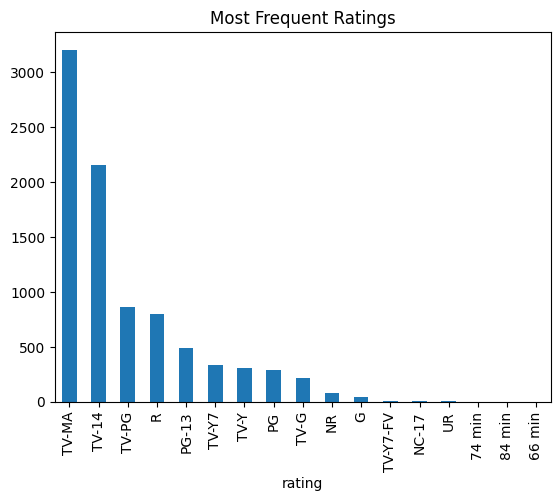

In [11]:
# Top ratings count
rating_counts = df['rating'].value_counts()
print(rating_counts.head(5))

# Visualization
rating_counts.plot(kind='bar', title='Most Frequent Ratings')

In [12]:
# Filter for TV-MA and see top countries
mature_content = df[df['rating'] == 'TV-MA']
mature_countries = mature_content['country'].value_counts().head(10)
print(mature_countries)

country
United States     928
India             248
United Kingdom    177
Spain             119
Japan              87
South Korea        85
France             80
Mexico             77
Turkey             63
Canada             61
Name: count, dtype: int64


In [13]:
# Comparing genres by type
genre_comparison = df.groupby(['type', 'listed_in']).size().reset_index(name='count')
# Top 5 for each
print(genre_comparison.sort_values(by='count', ascending=False).groupby('type').head(5))

        type                                          listed_in  count
217    Movie                       Dramas, International Movies    362
183    Movie                                      Documentaries    359
276    Movie                                    Stand-Up Comedy    334
142    Movie             Comedies, Dramas, International Movies    274
210    Movie   Dramas, Independent Movies, International Movies    252
433  TV Show                                           Kids' TV    220
423  TV Show                  International TV Shows, TV Dramas    121
346  TV Show  Crime TV Shows, International TV Shows, TV Dramas    110
444  TV Show                              Kids' TV, TV Comedies     99
452  TV Show                                         Reality TV     95


In [14]:
# US vs Rest of the World
us_genres = df[df['country'] == 'United States']['listed_in'].value_counts().head(5)
non_us_genres = df[df['country'] != 'United States']['listed_in'].value_counts().head(5)

print("Top US Genres:\n", us_genres)
print("\nTop International Genres:\n", non_us_genres)

Top US Genres:
 listed_in
Documentaries                         249
Stand-Up Comedy                       209
Children & Family Movies, Comedies     90
Dramas                                 88
Comedies                               84
Name: count, dtype: int64

Top International Genres:
 listed_in
Dramas, International Movies                        361
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Dramas, International Movies, Romantic Movies       179
Documentaries, International Movies                 178
Name: count, dtype: int64


In [16]:
# Filter by recent years (assuming 2026 current year, looking at 2023-2025)
recent_df = df[df['release_year'] >= 2023]
popular_recent_genres = recent_df['listed_in'].value_counts().head(10)
print(popular_recent_genres)

Series([], Name: count, dtype: int64)


In [21]:
top_directors = df.assign(director_list=df['director'].str.split(',')) \
                  .explode('director_list')['director_list'] \
                  .dropna() \
                  .value_counts() \
                  .head(10)

print(top_directors)

director_list
Rajiv Chilaka          22
 Jan Suter             18
RaÃºl Campos           18
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Jay Chapman            12
Martin Scorsese        12
Youssef Chahine        12
Name: count, dtype: int64


In [23]:
top_actors = df.assign(cast_list=df['cast'].str.split(',')) \
               .explode('cast_list')['cast_list'] \
               .dropna() \
               .value_counts() \
               .head(10)

print(top_actors)

cast_list
 Anupam Kher         39
 Rupa Bhimani        31
 Takahiro Sakurai    30
 Julie Tejwani       28
 Om Puri             27
 Rajesh Kava         26
Shah Rukh Khan       26
 Andrea Libman       25
 Paresh Rawal        25
 Boman Irani         25
Name: count, dtype: int64


In [24]:
dir_genre = df.assign(
    director_list=df['director'].str.split(','),
    listed_in=df['listed_in'].str.split(',')
).explode('director_list').explode('listed_in')

top_pairs = dir_genre.groupby(['director_list', 'listed_in']) \
                    .size() \
                    .sort_values(ascending=False) \
                    .head(10)

print(top_pairs)

director_list        listed_in               
Rajiv Chilaka        Children & Family Movies    22
 Jan Suter           Stand-Up Comedy             18
RaÃºl Campos         Stand-Up Comedy             18
Suhas Kadav          Children & Family Movies    16
Marcus Raboy         Stand-Up Comedy             15
Jay Karas            Stand-Up Comedy             14
Jay Chapman          Stand-Up Comedy             11
Cathy Garcia-Molina   International Movies       11
Youssef Chahine       International Movies       10
Don Michael Paul     Action & Adventure           9
dtype: int64


In [25]:
unknown_data = df[(df['director'].isna()) | (df['cast'].isna())].shape[0]

print(f"Titles with missing director or cast: {unknown_data}")

Titles with missing director or cast: 3107


In [26]:
movies = df[df['type'] == 'Movie'].copy()
movies['duration_min'] = pd.to_numeric(
    movies['duration'].str.replace(' min', '', regex=False),
    errors='coerce'
)

print(f"Average Movie Duration: {movies['duration_min'].mean():.2f} minutes")

Average Movie Duration: 99.58 minutes


In [27]:
vc = df[df['type'] == 'TV Show']['duration'].value_counts()
print(f"Most common TV show length: {vc.idxmax()} ({vc.max()} shows)")

Most common TV show length: 1 Season (1793 shows)


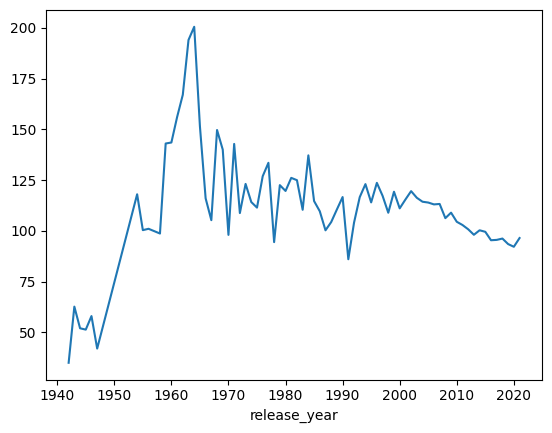

In [28]:
movies = df[df['type'] == 'Movie'].copy()
movies['duration_min'] = pd.to_numeric(
    movies['duration'].str.replace(' min', '', regex=False),
    errors='coerce'
)

duration_trend = movies.groupby('release_year')['duration_min'].mean()

duration_trend.plot(kind='line')
plt.show()

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

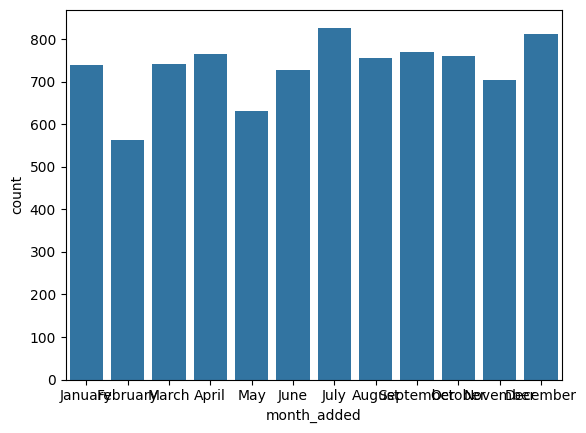

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['month_added'] = df['date_added'].dt.month_name()

order = ['January', 'February', 'March', 'April', 'May', 'June',
         'July', 'August', 'September', 'October', 'November', 'December']

sns.countplot(x='month_added', data=df, order=order)
plt.show()

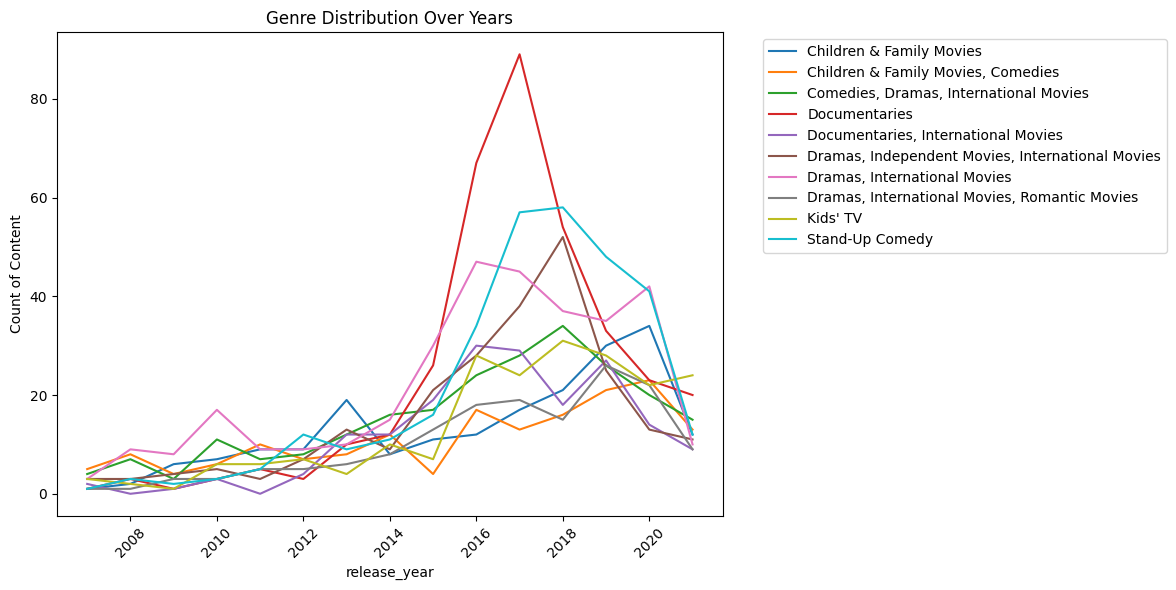

In [32]:
# Top 10 genres select karte hain analysis ke liye
top_genres = df['listed_in'].value_counts().nlargest(10).index
df_filtered = df[df['listed_in'].isin(top_genres)]

# Pivot table to see distribution
genre_trend = df_filtered.groupby(['release_year', 'listed_in']).size().unstack(fill_value=0)

# Last 10-15 years ka trend dekhne ke liye
genre_trend.tail(15).plot(kind='line', figsize=(12, 6))
plt.title('Genre Distribution Over Years')
plt.ylabel('Count of Content')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [33]:
# Cleaning: Splitting multiple countries and genres
df_exploded = df.assign(country=df['country'].str.split(', ')).explode('country')
df_exploded = df_exploded.assign(listed_in=df_exploded['listed_in'].str.split(', ')).explode('listed_in')

# Finding top country for each genre
top_countries_per_genre = df_exploded.groupby(['listed_in', 'country']).size().reset_index(name='count')
top_countries_per_genre = top_countries_per_genre.loc[top_countries_per_genre.groupby('listed_in')['count'].idxmax()]

# Har genre ka top performer dikhane ke liye
print(top_countries_per_genre.sort_values('count', ascending=False))

                         listed_in         country  count
667           International Movies           India    864
489                         Dramas   United States    835
225                       Comedies   United States    680
362                  Documentaries   United States    511
57              Action & Adventure   United States    404
135       Children & Family Movies   United States    390
628             Independent Movies   United States    390
1418                     Thrillers   United States    292
1207                   TV Comedies   United States    258
1267                     TV Dramas   United States    232
87                British TV Shows  United Kingdom    225
970                Romantic Movies   United States    225
1129               Stand-Up Comedy   United States    216
824                       Kids' TV   United States    214
560                  Horror Movies   United States    201
395                     Docuseries   United States    192
1047          